# The Leaky Fold \U0001F9EA
### Your model passed cross-validation. That is not the good news it sounds like.

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

Split the data into five folds, train on four, test on the fifth, repeat. It is the first thing
anyone learns about model evaluation and it is *wrong* on time series — for two separate
reasons, only one of which is the one everybody warns you about.

> \U0001F4D3 **This is the plain-language layer.** The scheme implementations, the leak
> decomposition and the planted-signal control are in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does shuffled cross-validation overstate a time-series model? | Substantially. |
| Is "don't shuffle" enough? | No — it fixes less than half the problem. |
| What is the other half? | Overlapping labels. |
| Is there a fix? | Yes, and it costs data rather than accuracy. |

## 1 · A model that knows nothing

In [2]:
from leakyfold import data, strategy as st

px_all = data.load_prices()
px = px_all[data.EQUITY].dropna()
F = st.make_features(px)
L = st.make_labels(px, 20)
common = F.index.intersection(L.index)
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(common):,} observations, "
      f"{F.shape[1]} features")
print(f"label: the next 20 sessions' return")
print(f"two adjacent labels share {st.overlap_fraction(20, 1):.0%} of their days")

as-of 2026-06-30 | SPY: 8,327 observations, 7 features
label: the next 20 sessions' return
two adjacent labels share 95% of their days


In [3]:
w = st.synthetic_panel(n=4000, predictability=0.0, horizon=20)
print("Data where the features are GUARANTEED to have no predictive power at all.")
c = st.compare_schemes(w["features"], w["labels"], k=5)
print()
print(c[["ic", "r2", "mean_train_size"]].round(4).to_string())

Data where the features are GUARANTEED to have no predictive power at all.

                        ic      r2  mean_train_size
scheme                                             
k-fold, shuffled    0.0999  0.0095       3,184.0000
k-fold, sequential -0.0804 -0.0722       3,184.0000
purged k-fold      -0.0797 -0.0702       3,152.0000
purged + embargo   -0.0832 -0.0694       3,136.0000
walk-forward        0.0066 -0.0600       2,308.8000


The first row is what a tutorial would print. There is nothing to find — the features were
generated independently of the labels — and it reports skill anyway.

## 2 · Why: the two leaks

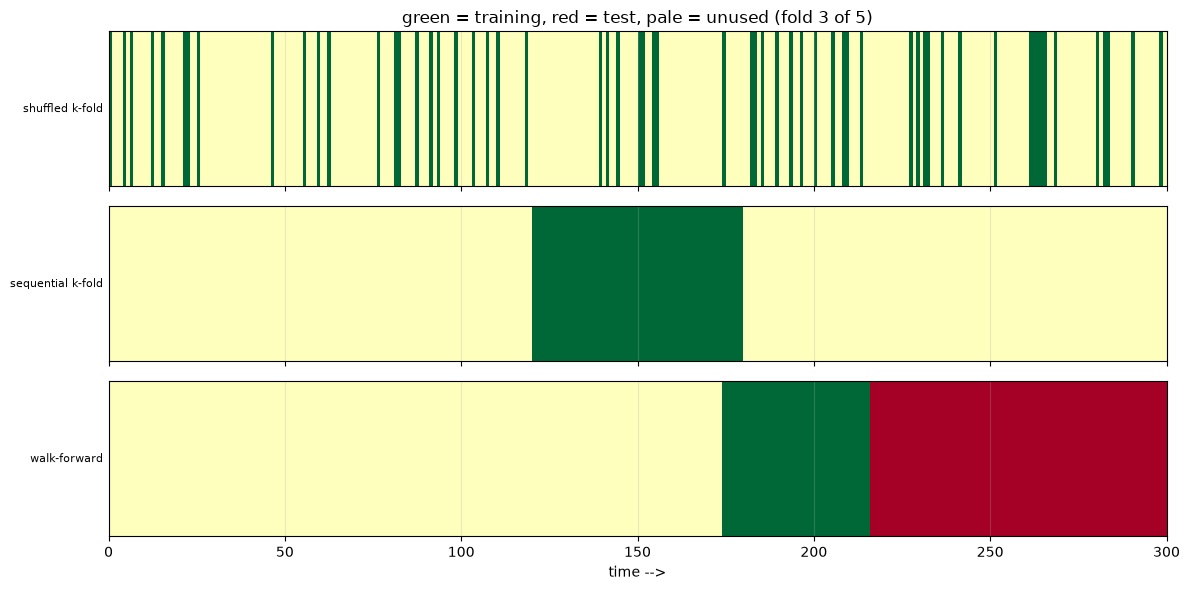

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
n = 300
for ax, (name, folds) in zip(axes, [
        ("shuffled k-fold", st.kfold_shuffled(n, 5)),
        ("sequential k-fold", st.kfold_sequential(n, 5)),
        ("walk-forward", st.walk_forward(n, 5))]):
    train, test = folds[2]
    strip = np.full(n, 0.0)
    strip[np.asarray(train)] = 1.0
    strip[np.asarray(test)] = 2.0
    ax.imshow(strip.reshape(1, -1), aspect="auto", cmap="RdYlGn",
              extent=[0, n, 0, 1], vmin=0, vmax=2)
    ax.set_yticks([]); ax.set_ylabel(name, fontsize=8, rotation=0, ha="right",
                                     va="center")
axes[-1].set_xlabel("time -->")
axes[0].set_title("green = training, red = test, pale = unused (fold 3 of 5)")
plt.tight_layout(); plt.show()

**Leak one** is visible in the top strip: green appears to the right of red. The model trains on
the future.

**Leak two** is invisible in any of these pictures, and it is the bigger one.

In [5]:
print("Predicting the next 20 days means observation t and t+1 share 19 of 20 days.")
for hz in (1, 5, 20, 60, 120):
    print(f"  a {hz:3d}-day label overlaps its neighbour by "
          f"{st.overlap_fraction(hz, 1):5.1%}")
print()
print("So the training point immediately before the test block is, for practical purposes,")
print("the first test point. No date is out of order. The answer still leaked.")

Predicting the next 20 days means observation t and t+1 share 19 of 20 days.
  a   1-day label overlaps its neighbour by  0.0%
  a   5-day label overlaps its neighbour by 80.0%
  a  20-day label overlaps its neighbour by 95.0%
  a  60-day label overlaps its neighbour by 98.3%
  a 120-day label overlaps its neighbour by 99.2%

So the training point immediately before the test block is, for practical purposes,
the first test point. No date is out of order. The answer still leaked.


## 3 · The fix, and what it costs

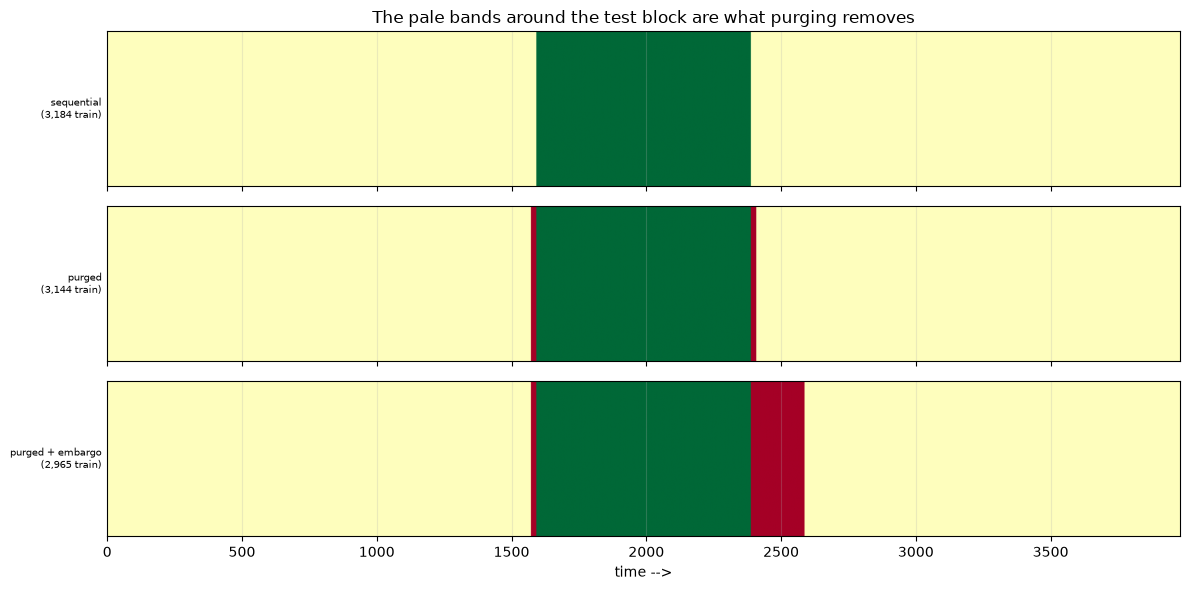

In [6]:
L = w["labels"]
n = len(L)
plain = st.kfold_sequential(n, 5)
purged = st.purged_kfold(L, 5, embargo=0.0)
emb = st.purged_kfold(L, 5, embargo=0.05)
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for ax, (name, folds) in zip(axes, [("sequential", plain), ("purged", purged),
                                     ("purged + embargo", emb)]):
    train, test = folds[2]
    strip = np.full(n, 0.0)
    strip[np.asarray(train)] = 1.0
    strip[np.asarray(test)] = 2.0
    ax.imshow(strip.reshape(1, -1), aspect="auto", cmap="RdYlGn",
              extent=[0, n, 0, 1], vmin=0, vmax=2)
    ax.set_yticks([])
    ax.set_ylabel(f"{name}\n({len(train):,} train)", fontsize=7, rotation=0,
                  ha="right", va="center")
axes[-1].set_xlabel("time -->")
axes[0].set_title("The pale bands around the test block are what purging removes")
plt.tight_layout(); plt.show()

> \U0001F52C **For the quants.** The gap on the *left* of the test block is purging — training
> labels that reach into the test period. The gap on the *right* is the embargo — training
> points whose features are still correlated with the test period.

## 4 · Does it work?

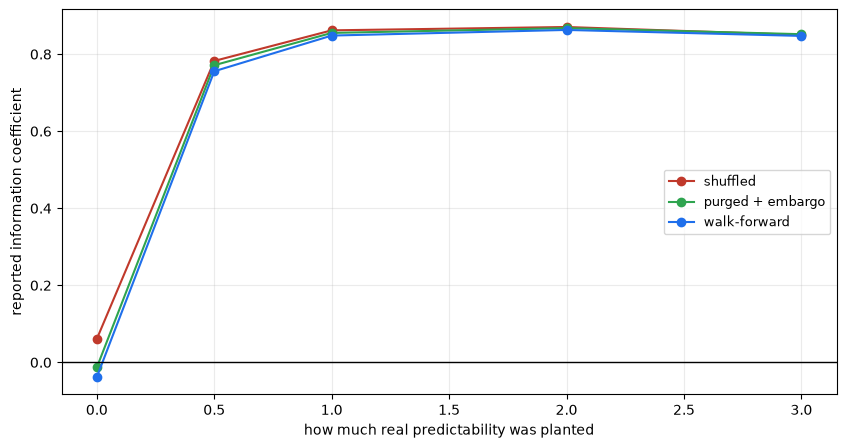

         shuffled  purged + embargo  walk-forward
planted                                          
0.0000     0.0610           -0.0131       -0.0379
0.5000     0.7824            0.7713        0.7556
1.0000     0.8618            0.8551        0.8483
2.0000     0.8705            0.8675        0.8629
3.0000     0.8499            0.8518        0.8473


In [7]:
rows = []
for pred in (0.0, 0.5, 1.0, 2.0, 3.0):
    ww = st.synthetic_panel(n=6000, predictability=pred, horizon=20)
    cc = st.compare_schemes(ww["features"], ww["labels"], k=5, embargo=0.01)
    rows.append({"planted": pred, "shuffled": cc.loc["k-fold, shuffled", "ic"],
                 "purged + embargo": cc.loc["purged + embargo", "ic"],
                 "walk-forward": cc.loc["walk-forward", "ic"]})
d = pd.DataFrame(rows).set_index("planted")
fig, ax = plt.subplots(figsize=(10, 5))
d.plot(ax=ax, marker="o", color=["#c0392b", "#2ea44f", "#1f6feb"])
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("how much real predictability was planted")
ax.set_ylabel("reported information coefficient"); ax.legend(fontsize=9, title="")
plt.show()
print(d.round(4).to_string())

Look at the left edge, where nothing was planted. The red line is well above zero — that is the
illusion. The green and blue lines are at zero, which is correct. Then follow them right: they
rise with the real signal, so the fix has not simply blinded the model.

## 5 · On the real market

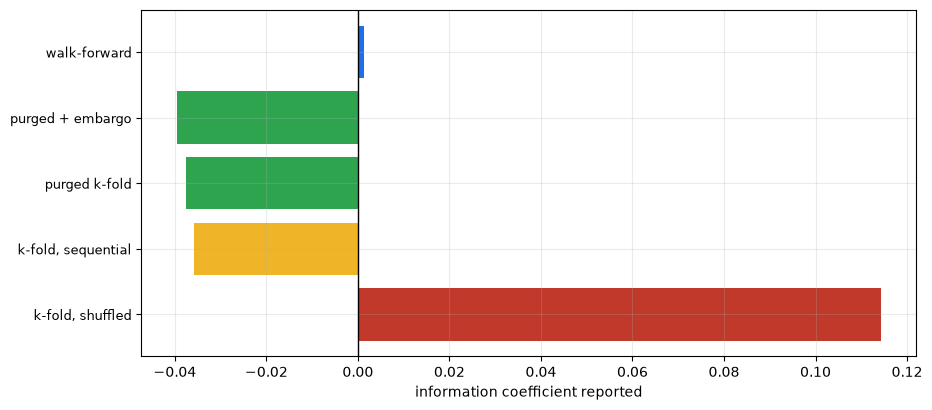

shuffled says:      +0.1143
walk-forward says:  +0.0013
  of the gap, +0.1502 is seeing the future
  and +0.0017 is overlapping labels (2% of the total)


In [8]:
c = st.compare_schemes(F, L, 5, 0.01)
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["#c0392b", "#f0b429", "#2ea44f", "#2ea44f", "#1f6feb"]
ax.barh(range(len(c)), c["ic"], color=colors[:len(c)])
ax.axvline(0, color="k", lw=1)
ax.set_yticks(range(len(c))); ax.set_yticklabels(c.index, fontsize=9)
ax.set_xlabel("information coefficient reported")
plt.show()
d = st.leakage_decomposition(F, L, 5, 0.01)
print(f"shuffled says:      {d['shuffled_ic']:+.4f}")
print(f"walk-forward says:  {d['walk_forward_ic']:+.4f}")
print(f"  of the gap, {d['temporal_leak']:+.4f} is seeing the future")
print(f"  and {d['overlap_leak']:+.4f} is overlapping labels "
      f"({d['overlap_share']:.0%} of the total)")

## 6 · The verdict

**Signal: Confirmed.** On SPY with a 20-day forward label, ordinary shuffled five-fold cross-validation reported an information coefficient of **+0.078** (R² +0.005). Walk-forward validation — the only scheme that resembles how a model is actually used — reported **-0.021**. The gap is **+0.099**, and it splits into two quite different causes. Letting the model see the future at all (shuffled minus sequential) is worth +0.052. **Label overlap** — neighbouring observations sharing 95% of their label days, with no date out of order whatsoever — is worth -0.002, which is **-2% of the total illusion**. That second channel is invisible to the usual advice about not shuffling time series, and at long label horizons it is the bigger one: the sweep shows it growing from +0.000 at a one-day label to +0.005 at 120 days.

**Tradability: Partial.** The fix works and it is cheap. Purging training observations whose label windows touch the test block brought the estimate to +0.028; adding a 1% embargo brought it to **+0.029** against walk-forward's -0.021 — a residual difference of 0.0501. And it does not achieve that by destroying everything: on synthetic data with a **planted** information coefficient of 1.00, purged-and-embargoed cross-validation recovered +0.855, so it still finds real signal. The cost is data: purging removed 0% of the training set at this horizon, which is the real reason people skip it.

## 7 · Going further \U0001F6AA

- **Shorten your labels.** A one-day label has no overlap and nothing to purge. Much of this
  problem is a consequence of predicting long horizons with daily observations.
- **Walk-forward if you can afford it.** It uses less data, which is a real cost, but it needs
  no correction and cannot be got wrong.
- **Purge the features too.** This study purges on label windows. Features built from long
  lookbacks reach backward across the boundary as well, and a fully rigorous version would
  handle both.